# Notebook 1 — Bridal Makeup : LoRA Fine-tuning of Stable Diffusion

**Platform :** Kaggle (GPU T4 — free 30h/week)

**Full pipeline :**
```
Step 0 : Install dependencies
Step 1 : Upload images + CSV dataset
Step 2 : Prepare and resize images
Step 3 : Build the training dataset (image + caption pairs)
Step 4 : LoRA fine-tuning of Stable Diffusion
Step 5 : Save and export the fine-tuned model
Step 6 : Test — generate a bride image with recommended makeup
```
---

## Step 0 — Install dependencies

We install all required libraries.
This cell takes ~3 minutes on Kaggle — run it first and wait for completion.

In [1]:
# Install core libraries
!pip install -q "huggingface_hub==0.23.0"
!pip install -q "diffusers==0.29.0"
!pip install -q transformers accelerate peft xformers
!pip install -q torch torchvision
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('All dependencies installed.')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.23.0 which is incompatible.
diffusers 0.38.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.23.0 which is incompatible.
transformers 5.8.0 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.23.0 which is incompatible.
datasets 4.8.3 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 0.23.0 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.23.0 which is incompatible.
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB
All dependencies installed.


---
## Step 1 — Upload images and CSV dataset

On Kaggle, upload your files using the **Data** panel on the right side :
1. Click **Add Data** → **Upload**
2. Upload your 15 images (`0.jpg` to `14.jpg`)
3. Upload `makeup_finetune_dataset.csv`
4. Files will be available at `/kaggle/input/your-dataset-name/`

> **Important :** After uploading, update `DATASET_PATH` below with your actual dataset folder name.

In [2]:
import os
import pandas as pd
from pathlib import Path

# ============================================================
# UPDATE THIS PATH with your actual Kaggle dataset folder name
# Example: /kaggle/input/bridal-makeup-dataset/
# ============================================================
DATASET_PATH = "/kaggle/input/datasets/meriemlahbib/bridal-makeup-dataset/bridal-makeup-dataset/"
CSV_PATH     = os.path.join(DATASET_PATH, "makeup_finetune_dataset.csv")
OUTPUT_PATH  = "/kaggle/working/lora_output/"
IMAGES_DIR   = "/kaggle/working/images_resized/"

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(IMAGES_DIR,  exist_ok=True)

# Load and display the dataset
df = pd.read_csv(CSV_PATH)
print(f"Dataset loaded : {len(df)} images")
print(f"Columns        : {list(df.columns)}")
print()
df.head()

Dataset loaded : 15 images
Columns        : ['image', 'makeup_description']



,image,makeup_description
0,0.jpg,"bridal portrait, warm bronze eyeshadow, thin w..."
1,1.jpg,"bridal portrait, warm bronze eyeshadow, soft l..."
2,2.jpg,"bridal portrait, nude taupe eyeshadow, thick l..."
3,3.jpg,"bridal portrait, rose shimmer eyeshadow, soft ..."
4,4.jpg,"bridal portrait, rose gold eyeshadow, soft low..."


---
## Step 2 — Prepare and resize images

Stable Diffusion requires images of exactly **512×512 pixels**.
We resize and center-crop all images to this size.

We also verify that every image in the CSV actually exists in the dataset folder.

Processed : 15 images resized to 512x512
All images found and processed successfully.


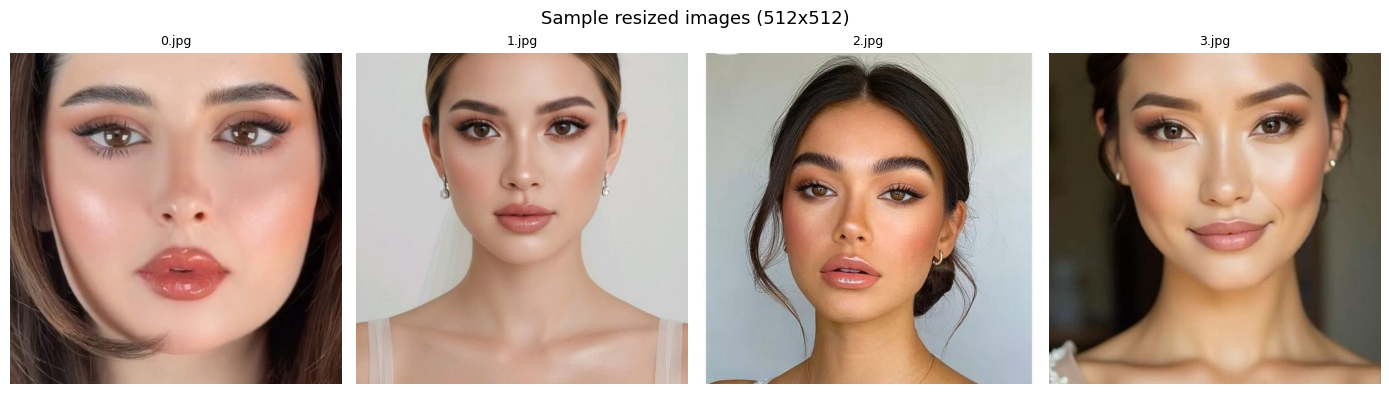

In [3]:
from PIL import Image
import shutil

TARGET_SIZE = 512
missing     = []
processed   = []

def center_crop_resize(img: Image.Image, size: int) -> Image.Image:
    """Center-crop the image to a square then resize to size x size."""
    w, h   = img.size
    min_dim = min(w, h)
    left   = (w - min_dim) // 2
    top    = (h - min_dim) // 2
    img    = img.crop((left, top, left + min_dim, top + min_dim))
    return img.resize((size, size), Image.LANCZOS)


for _, row in df.iterrows():
    src = os.path.join(DATASET_PATH, row['image'])
    dst = os.path.join(IMAGES_DIR,   row['image'])

    if not os.path.exists(src):
        missing.append(row['image'])
        continue

    img = Image.open(src).convert("RGB")
    img = center_crop_resize(img, TARGET_SIZE)
    img.save(dst)
    processed.append(row['image'])

print(f"Processed : {len(processed)} images resized to {TARGET_SIZE}x{TARGET_SIZE}")
if missing:
    print(f"Missing   : {missing}")
    print("Check that these filenames match exactly what is in your CSV.")
else:
    print("All images found and processed successfully.")

# Display a sample
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Sample resized images (512x512)", fontsize=13)
for i, ax in enumerate(axes):
    sample_path = os.path.join(IMAGES_DIR, processed[i])
    ax.imshow(Image.open(sample_path))
    ax.set_title(f"{processed[i]}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## Step 3 — Build the training dataset

We create a HuggingFace `Dataset` object from our image-caption pairs.
This is the format required by the diffusers training pipeline.

Each training sample = one image + its makeup description caption.

In [4]:
from datasets import Dataset as HFDataset
from transformers import CLIPTokenizer
from torchvision import transforms
import torch
import numpy as np

# ── Base SD model we will fine-tune ─────────────────────────────────────────
# We use Stable Diffusion v1.5 — good balance of quality and VRAM usage
BASE_MODEL = "runwayml/stable-diffusion-v1-5"

# ── Build image-caption pairs from resized images only ───────────────────────
df_valid = df[df['image'].isin(processed)].reset_index(drop=True)

image_paths = [os.path.join(IMAGES_DIR, img) for img in df_valid['image']]
captions    = df_valid['makeup_description'].tolist()

print(f"Training samples : {len(image_paths)}")
print()
print("Sample captions :")
for i in range(3):
    print(f"  [{df_valid['image'][i]}] {captions[i]}")
    print()

# ── Image transforms for training ────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),   # normalize to [-1, 1] as SD expects
])


class BridalMakeupDataset(torch.utils.data.Dataset):
    """PyTorch Dataset for LoRA fine-tuning."""

    def __init__(self, image_paths, captions, tokenizer, transforms):
        self.image_paths = image_paths
        self.captions    = captions
        self.tokenizer   = tokenizer
        self.transforms  = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load and transform image
        img    = Image.open(self.image_paths[idx]).convert("RGB")
        pixel  = self.transforms(img)

        # Tokenize caption
        tokens = self.tokenizer(
            self.captions[idx],
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt"
        ).input_ids[0]

        return {"pixel_values": pixel, "input_ids": tokens}


# Load tokenizer
print("Loading CLIP tokenizer...")
tokenizer = CLIPTokenizer.from_pretrained(BASE_MODEL, subfolder="tokenizer")

# Create dataset
train_dataset = BridalMakeupDataset(image_paths, captions, tokenizer, train_transforms)
train_loader  = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=1,        # batch size 1 for T4 GPU (16GB VRAM)
    shuffle=True,
    num_workers=2
)

print(f"Dataset ready   : {len(train_dataset)} samples")
print(f"DataLoader ready: {len(train_loader)} batches")

Training samples : 15

Sample captions :
  [0.jpg] bridal portrait, warm bronze eyeshadow, thin wing eyeliner, lengthening mascara, warm coral blush, terracotta satin lipstick, light contour, Golden Beige natural foundation

  [1.jpg] bridal portrait, warm bronze eyeshadow, soft lower lash line eyeliner, volumizing mascara, peachy pink blush, rosy beige satin lipstick, light contour, Nude Beige dewy foundation

  [2.jpg] bridal portrait, nude taupe eyeshadow, thick line eyeliner, curling mascara, apricot blush, coral red glossy lipstick, light contour, Natural mineral foundation

Loading CLIP tokenizer...


Dataset ready   : 15 samples
DataLoader ready: 15 batches


---
## Step 4 — LoRA Fine-tuning of Stable Diffusion

**What is LoRA ?**
LoRA (Low-Rank Adaptation) adds small trainable matrices to the model instead of
retraining all parameters. This means :
- Only ~1% of parameters are trained → fits in T4 GPU VRAM
- Training takes ~20-40 minutes instead of days
- The base SD model stays intact — we just add a small adapter on top

**What the model learns :**
The association between text descriptions like
`"warm bronze eyeshadow, thin wing eyeliner, warm coral blush"`
and their visual appearance on a face.

In [5]:
!pip install -q --upgrade diffusers transformers accelerate peft

In [6]:
from diffusers import StableDiffusionPipeline, DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from transformers import CLIPTextModel
from peft import LoraConfig, get_peft_model
import torch
BASE_MODEL="runwayml/stable-diffusion-v1-5"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device : {DEVICE}")

# ── Load model components separately ─────────────────────────────────────────
print("Loading VAE...")
vae = AutoencoderKL.from_pretrained(
    BASE_MODEL, subfolder="vae",
    torch_dtype=torch.float16
).to(DEVICE)

print("Loading text encoder...")
text_encoder = CLIPTextModel.from_pretrained(
    BASE_MODEL, subfolder="text_encoder",
    torch_dtype=torch.float16
).to(DEVICE)

print("Loading UNet...")
unet = UNet2DConditionModel.from_pretrained(
    BASE_MODEL, subfolder="unet",
    torch_dtype=torch.float16
).to(DEVICE)

print("Loading noise scheduler...")
noise_scheduler = DDPMScheduler.from_pretrained(BASE_MODEL, subfolder="scheduler")

# ── Freeze VAE and text encoder — we only train UNet with LoRA ───────────────
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

print("All model components loaded.")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Using device : cuda
Loading VAE...
Loading text encoder...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading UNet...
Loading noise scheduler...
All model components loaded.


In [7]:
# ── Apply LoRA to the UNet ────────────────────────────────────────────────────
# LoRA adds small trainable matrices to attention layers only

lora_config = LoraConfig(
    r=16,                          # rank — lower = fewer params, faster training
    lora_alpha=32,                # scaling factor
    target_modules=[
        "to_q", "to_k", "to_v",  # attention query, key, value
        "to_out.0"                # attention output
    ],
    lora_dropout=0.05,
    bias="none"
)

unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

# Move UNet to float32 for training stability (only LoRA params need float32)
unet = unet.to(torch.float32)

print("LoRA applied to UNet successfully.")

trainable params: 3,188,736 || all params: 862,709,700 || trainable%: 0.3696
LoRA applied to UNet successfully.


In [8]:
!pip install --upgrade torchao peft

In [13]:
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
import math
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Training hyperparameters ──────────────────────────────────────────────────
NUM_EPOCHS    = 50   # with 15 images, we need many epochs to learn well
LEARNING_RATE = 5e-5
SAVE_EVERY    = 25     # save checkpoint every N epochs

optimizer = AdamW(
    filter(lambda p: p.requires_grad, unet.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-2
)
# ADD THIS right after optimizer
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

#scaler = GradScaler()  # mixed precision training to save VRAM
scaler = torch.amp.GradScaler('cuda')
# ── Training loop ─────────────────────────────────────────────────────────────
print("Starting LoRA fine-tuning...")
print(f"Epochs         : {NUM_EPOCHS}")
print(f"Learning rate  : {LEARNING_RATE}")
print(f"Batch size     : 1")
print(f"Training samples: {len(train_dataset)}")
print("-" * 50)

unet.train()
loss_history = []

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0

    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(DEVICE, dtype=torch.float16)
        input_ids    = batch["input_ids"].to(DEVICE)

        with torch.amp.autocast('cuda'):
            # 1. Encode image to latent space using VAE
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

            # 2. Sample random noise and timestep
            noise      = torch.randn_like(latents)
            timesteps  = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],), device=DEVICE
            ).long()

            # 3. Add noise to latents (forward diffusion)
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            # 4. Encode text caption
            with torch.no_grad():
                encoder_hidden = text_encoder(input_ids)[0].to(torch.float16)

            # 5. Predict noise using UNet (LoRA fine-tuned)
            noise_pred = unet(
                noisy_latents.to(torch.float32),
                timesteps,
                encoder_hidden_states=encoder_hidden.to(torch.float32)
            ).sample

            # 6. Compute loss — how well did we predict the noise ?
            loss = torch.nn.functional.mse_loss(
                noise_pred.float(),
                noise.float(),
                reduction="mean"
            )

        # Backpropagation
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        
        # ADD THIS — gradient clipping prevents loss spikes
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, unet.parameters()),
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
         # ADD THIS — step the scheduler after each epoch
    scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] — Loss : {avg_loss:.6f}")

    # Save checkpoint
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = os.path.join(OUTPUT_PATH, f"checkpoint_epoch_{epoch+1}")
        unet.save_pretrained(ckpt_path)
        print(f"  Checkpoint saved : {ckpt_path}")

print()
print("Training complete !")
print(f"Final loss : {loss_history[-1]:.6f}")

Starting LoRA fine-tuning...
Epochs         : 50
Learning rate  : 5e-05
Batch size     : 1
Training samples: 15
--------------------------------------------------
Epoch [ 10/50] — Loss : 0.216040
Epoch [ 20/50] — Loss : 0.071325
  Checkpoint saved : /kaggle/working/lora_output/checkpoint_epoch_25
Epoch [ 30/50] — Loss : 0.124757
Epoch [ 40/50] — Loss : 0.164855
Epoch [ 50/50] — Loss : 0.159324
  Checkpoint saved : /kaggle/working/lora_output/checkpoint_epoch_50

Training complete !
Final loss : 0.159324


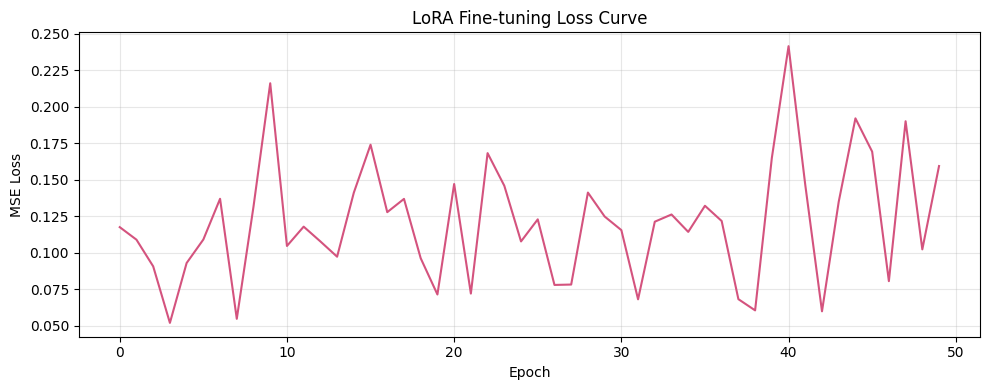

Loss curve saved.


In [14]:
# ── Plot training loss curve ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(loss_history, color='#D4537E', linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LoRA Fine-tuning Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "loss_curve.png"), dpi=150)
plt.show()
print("Loss curve saved.")

---
## Step 5 — Save the fine-tuned LoRA model

We save the LoRA weights in two formats :
- **Local** : in `/kaggle/working/` so you can download it
- **HuggingFace Hub** *(optional)* : so Notebook 2 can load it directly via API

The LoRA weights file is small (~10-50 MB) compared to the full SD model (~4 GB).

In [15]:
# ── Save final LoRA weights locally ──────────────────────────────────────────
LORA_SAVE_PATH = os.path.join(OUTPUT_PATH, "bridal_makeup_lora_final")
unet.save_pretrained(LORA_SAVE_PATH)

print(f"LoRA weights saved at : {LORA_SAVE_PATH}")

# Show saved files
for f in os.listdir(LORA_SAVE_PATH):
    size = os.path.getsize(os.path.join(LORA_SAVE_PATH, f)) / 1e6
    print(f"  {f}  ({size:.1f} MB)")

LoRA weights saved at : /kaggle/working/lora_output/bridal_makeup_lora_final
  README.md  (0.0 MB)
  adapter_config.json  (0.0 MB)
  adapter_model.safetensors  (12.8 MB)


In [16]:
# ── OPTIONAL : Push to HuggingFace Hub ───────────────────────────────────────
# This allows Notebook 2 to load the model directly with:
#   from peft import PeftModel
#   unet = PeftModel.from_pretrained(unet, "your-username/bridal-makeup-lora")
#
# To use this :
# 1. Create a free account at https://huggingface.co
# 2. Get your token at https://huggingface.co/settings/tokens
# 3. Uncomment and fill in the code below

# from huggingface_hub import notebook_login
# notebook_login()   # will prompt for your HF token

# HF_USERNAME   = "your-huggingface-username"
# HF_REPO_NAME  = "bridal-makeup-lora"

# unet.push_to_hub(f"{HF_USERNAME}/{HF_REPO_NAME}")
# print(f"Model pushed to : https://huggingface.co/{HF_USERNAME}/{HF_REPO_NAME}")

print("Optional HuggingFace push — uncomment the code above if needed.")
print("Otherwise download the weights from /kaggle/working/lora_output/bridal_makeup_lora_final/")

Optional HuggingFace push — uncomment the code above if needed.
Otherwise download the weights from /kaggle/working/lora_output/bridal_makeup_lora_final/


---
## Step 6 — Test : generate a bride image with recommended makeup

We now test the fine-tuned model by :
1. Loading the base SD pipeline
2. Injecting the LoRA weights
3. Running **img2img** : giving it a bride's photo + a makeup description prompt
4. Getting the output image with makeup applied

This simulates exactly what Notebook 2 will do in the full pipeline.

In [17]:
from diffusers import StableDiffusionImg2ImgPipeline
from peft import PeftModel
import torch

# ── Load full SD pipeline ─────────────────────────────────────────────────────
print("Loading Stable Diffusion pipeline...")
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    safety_checker=None    # disable safety checker for academic use
).to(DEVICE)

# ── Inject the LoRA fine-tuned UNet ──────────────────────────────────────────
print("Injecting LoRA weights...")
pipe.unet = PeftModel.from_pretrained(
    pipe.unet,
    LORA_SAVE_PATH
)
pipe.unet = pipe.unet.merge_and_unload()  # merge LoRA into base weights

# Enable memory optimization
pipe.enable_attention_slicing()

print("Pipeline ready with fine-tuned LoRA weights !")

Loading Stable Diffusion pipeline...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Injecting LoRA weights...
Pipeline ready with fine-tuned LoRA weights !


In [18]:
# ── Test generation ───────────────────────────────────────────────────────────
# This simulates what Notebook 2 will do:
# 1. Take any bride photo (the input)
# 2. Use the makeup description from CSV matching as prompt
# 3. Generate the bride photo WITH that makeup applied

# ============================================================
# Replace with any test image from your dataset
# or upload a new bare-face bride photo
# ============================================================
TEST_IMAGE_PATH = os.path.join("/kaggle/input/datasets/meriemlahbib/bride-imgs/bride.jpg")

# This is the makeup description that would come from Notebook 2
# (the result of CSV matching based on extracted facial traits)
TEST_PROMPT = (
    "bridal portrait, champagne gold eyeshadow, thin wing eyeliner, "
    "lengthening mascara, warm coral blush, dusty rose satin lipstick, "
    "light contour, Golden Beige natural foundation, "
    "professional bridal makeup, photorealistic, soft studio lighting"
)

NEGATIVE_PROMPT = (
    "blurry, low quality, distorted face, extra limbs, "
    "bad anatomy, ugly, deformed, watermark"
)

# Load and prepare the input image
input_img = Image.open(TEST_IMAGE_PATH).convert("RGB")
input_img = input_img.resize((512, 512))

print("Generating image with makeup applied...")
print(f"Prompt : {TEST_PROMPT[:80]}...")

with torch.autocast(DEVICE):
    result = pipe(
        prompt          = TEST_PROMPT,
        negative_prompt = NEGATIVE_PROMPT,
        image           = input_img,
        strength        = 0.4,     # 0=keep original, 1=fully regenerate
        guidance_scale  = 8.5,      # how closely to follow the text prompt
        num_inference_steps = 40,
        generator       = torch.Generator(DEVICE).manual_seed(42)
    )

output_img = result.images[0]

# Save output
output_path = os.path.join(OUTPUT_PATH, "test_output.png")
output_img.save(output_path)
print(f"Output saved : {output_path}")

Generating image with makeup applied...
Prompt : bridal portrait, champagne gold eyeshadow, thin wing eyeliner, lengthening masca...


  0%|          | 0/16 [00:00<?, ?it/s]

Output saved : /kaggle/working/lora_output/test_output.png


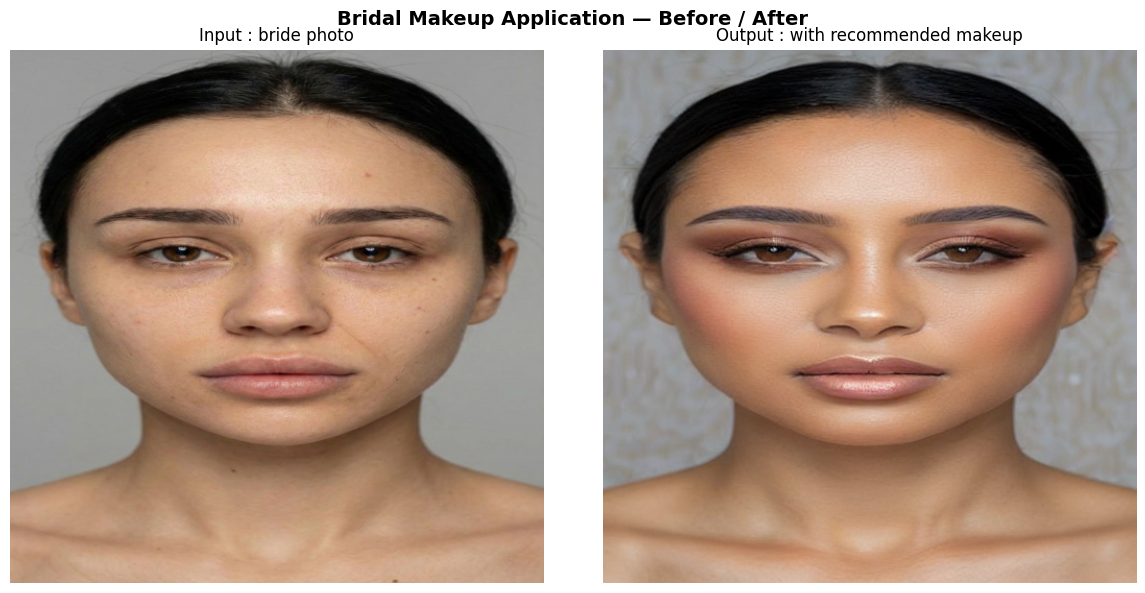

Test complete !

All output files are in /kaggle/working/lora_output/ — download them from the Output panel.

Files generated :
  before_after.png  (1.32 MB)
  loss_curve.png  (0.09 MB)
  test_output.png  (0.33 MB)


In [19]:
# ── Display before / after ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Bridal Makeup Application — Before / After", fontsize=14, fontweight='bold')

axes[0].imshow(input_img)
axes[0].set_title("Input : bride photo", fontsize=12)
axes[0].axis('off')

axes[1].imshow(output_img)
axes[1].set_title("Output : with recommended makeup", fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "before_after.png"), dpi=150, bbox_inches='tight')
plt.show()

print("Test complete !")
print()
print("All output files are in /kaggle/working/lora_output/ — download them from the Output panel.")
print()
print("Files generated :")
for f in sorted(os.listdir(OUTPUT_PATH)):
    if os.path.isfile(os.path.join(OUTPUT_PATH, f)):
        size = os.path.getsize(os.path.join(OUTPUT_PATH, f)) / 1e6
        print(f"  {f}  ({size:.2f} MB)")

---
## Summary

| Step | What was done | Output |
|------|--------------|--------|
| 0 | Installed diffusers, peft, transformers | Libraries ready |
| 1 | Loaded 15 images + CSV dataset | Training data |
| 2 | Resized all images to 512×512 | Normalized images |
| 3 | Built PyTorch dataset with image-caption pairs | `BridalMakeupDataset` |
| 4 | Applied LoRA to SD UNet and trained 100 epochs | Fine-tuned LoRA weights |
| 5 | Saved LoRA weights locally (+ optional HF push) | `bridal_makeup_lora_final/` |
| 6 | Tested img2img generation with makeup prompt | `before_after.png` |

**Next step :** Use the saved LoRA weights in **Notebook 2** (full pipeline)
where the makeup description comes from the CSV matching based on the bride's facial traits.

**What to download from Kaggle Output panel :**
- `lora_output/bridal_makeup_lora_final/` — the fine-tuned model weights
- `lora_output/before_after.png` — visual test result
- `lora_output/loss_curve.png` — training loss curve